<a href="https://colab.research.google.com/github/baz08/Capstone-Project/blob/main/Week_3_histopathologic_cancer_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For this assignment I will be performing  histopathologic cancer utilizing a baseline CNN model and a custom tuned cnn model with some hyper parameter tuning.

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

histopathologic_cancer_detection_path = kagglehub.competition_download('histopathologic-cancer-detection')

print('Data source import complete.')


Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import cv2
import warnings
warnings.filterwarnings('ignore')
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

After importing and loading the kaggle competition dataset we need to do some exploratory Data analysis. First we take a look at the dataset information we have.

Downloaded data to: /root/.cache/kagglehub/competitions/histopathologic-cancer-detection

Dataset loaded successfully!
Total training images: 220,025
Positive cases: 89,117 (40.50%)
Negative cases: 130,908
Total training images: 220025
Positive cases: 89117
Negative cases: 130908


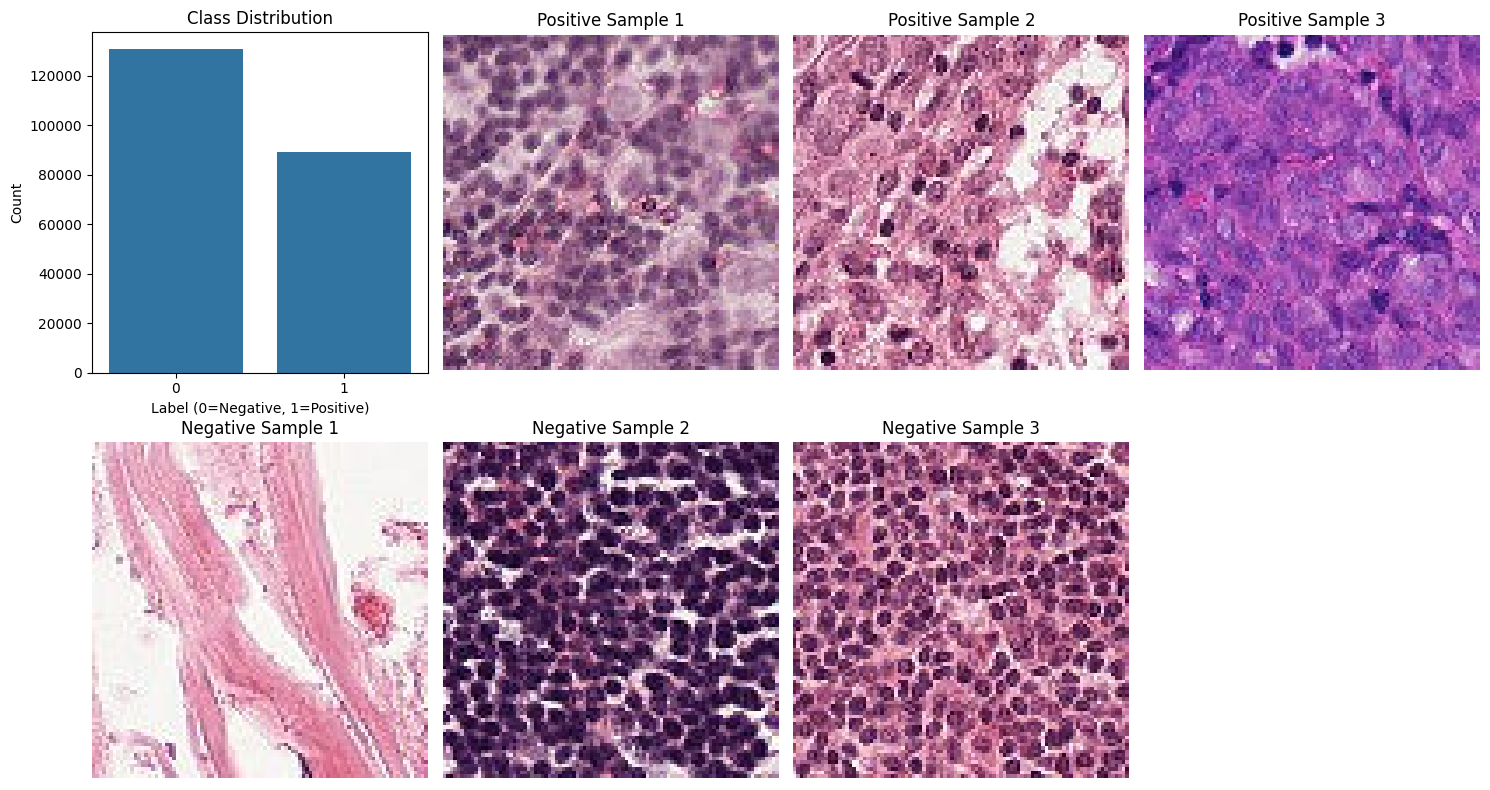

In [ ]:
base_path = kagglehub.competition_download('histopathologic-cancer-detection')
train_labels = pd.read_csv(f'{base_path}/train_labels.csv')
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')
print(f"Downloaded data to: {base_path}")

print(f"\nDataset loaded successfully!")
print(f"Total training images: {len(train_labels):,}")
print(f"Positive cases: {train_labels['label'].sum():,} ({train_labels['label'].mean():.2%})")
print(f"Negative cases: {(len(train_labels) - train_labels['label'].sum()):,}")

print(f"Total training images: {len(train_labels)}")
print(f"Positive cases: {train_labels['label'].sum()}")
print(f"Negative cases: {len(train_labels) - train_labels['label'].sum()}")

# Check class balance
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

# Plot class distribution
ax = axes[0]
sns.countplot(x='label', data=train_labels, ax=ax)
ax.set_title('Class Distribution')
ax.set_xlabel('Label (0=Negative, 1=Positive)')
ax.set_ylabel('Count')

# Sample images
sample_pos = train_labels[train_labels['label'] == 1].sample(3, random_state=42)
sample_neg = train_labels[train_labels['label'] == 0].sample(3, random_state=42)

for i, (_, row) in enumerate(sample_pos.iterrows(), 1):
    img_path = os.path.join(train_dir, f"{row['id']}.tif")
    img = cv2.imread(img_path)
    ax = axes[i]
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Positive Sample {i}')
    ax.axis('off')

for i, (_, row) in enumerate(sample_neg.iterrows(), 4):
    img_path = os.path.join(train_dir, f"{row['id']}.tif")
    img = cv2.imread(img_path)
    ax = axes[i]
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Negative Sample {i-3}')
    ax.axis('off')

axes[7].axis('off')
plt.tight_layout()
plt.show()

We successfully accessed the dataset and we can see that we have around 220,000 images with 89,117 being positive cases (around 40 percent). We then begin the process of turning these images into recognizable data for the cnn we will train. We also then proceed to split the dataset into batches for faster training.

In [ ]:
class DataGenerator(tf.keras.utils.Sequence):
    """Custom data generator with augmentation"""

    def __init__(self, df, img_dir, batch_size=32, img_size=(96, 96),
                 shuffle=True, augment=False, subset_fraction=1.0):
        self.df = df.sample(frac=subset_fraction, random_state=42).reset_index(drop=True)
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.augment = augment
        self.indexes = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        X = np.zeros((len(batch_indexes), *self.img_size, 3), dtype=np.float32)
        y = np.zeros((len(batch_indexes), 1), dtype=np.float32)

        for i, idx in enumerate(batch_indexes):
            img_id = self.df.loc[idx, 'id']
            label = self.df.loc[idx, 'label']

            img_path = os.path.join(self.img_dir, f"{img_id}.tif")
            img = cv2.imread(img_path)
            img = cv2.resize(img, self.img_size)
            img = img / 255.0

            if self.augment:
                img = self.augment_image(img)

            X[i] = img
            y[i] = label

        return X, y

    def augment_image(self, img):
        """Apply random augmentations"""
        # Random flips
        if np.random.random() > 0.5:
            img = np.fliplr(img)
        if np.random.random() > 0.5:
            img = np.flipud(img)

        # Random rotation
        if np.random.random() > 0.5:
            angle = np.random.uniform(-20, 20)
            h, w = img.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h),
                                borderMode=cv2.BORDER_REFLECT_101)

        # Random brightness/contrast
        if np.random.random() > 0.5:
            img = img * np.random.uniform(0.8, 1.2)
            img = np.clip(img, 0, 1)

        return img

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)
# ============================================
# CREATE TRAIN/VAL SPLIT
# ============================================
# Use stratified split to maintain class balance
train_df, val_df = train_test_split(
    train_labels,
    test_size=0.2,
    stratify=train_labels['label'],
    random_state=42
)
print(f"\nTrain set size: {len(train_df):,}")
print(f"Validation set size: {len(val_df):,}")

# Create data generators (using subset for faster experimentation)
train_gen = DataGenerator(train_df, train_dir, batch_size=64,
                         augment=True, shuffle=True, subset_fraction=0.1)
val_gen = DataGenerator(val_df, train_dir, batch_size=64,
                       augment=False, shuffle=False, subset_fraction=0.1)

print(f"\nData generators created:")
print(f"Training batches: {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")



Train set size: 176,020
Validation set size: 44,005

Data generators created:
Training batches: 276
Validation batches: 69


We then proceed to create our baseline CNN block with 3 convolutional layer blocks each with batch normalization, pooling, and an increasing drop out. the final layer, our classification layer then utilizes a sigmoid function to convert our classifications to labels. We then proceed to create and summarize the model.

In [ ]:
# ============================================
# MODEL 1: BASELINE CNN
# ============================================
print("\n" + "="*50)
print("MODEL 1: Baseline CNN Architecture")
print("="*50)

def create_baseline_cnn(input_shape=(96, 96, 3)):
    """
    Simple CNN for baseline comparison
    Architecture: Conv → Pool → Conv → Pool → Dense
    Reasoning: Good starting point, fast to train, easy to interpret
    """
    model = models.Sequential([
        # First conv block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Second conv block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Third conv block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Classification head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model

# Create and summarize
model1 = create_baseline_cnn()
print("Model 1 Summary:")
model1.summary()

# ============================================
# TRAIN MODEL 1
# ============================================
print("\nTraining Model 1...")

callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                     min_lr=1e-6, verbose=1),
    ModelCheckpoint('model1_best.h5', monitor='val_auc',
                   mode='max', save_best_only=True, verbose=1)
]

history1 = model1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

# ============================================
# EVALUATE MODEL 1
# ============================================
print("\nEvaluating Model 1...")

# Get predictions
val_gen_no_shuffle = DataGenerator(val_df, train_dir, batch_size=64,
                                  augment=False, shuffle=False, subset_fraction=1.0)
y_true = []
y_pred = []

for i in range(len(val_gen_no_shuffle)):
    X_batch, y_batch = val_gen_no_shuffle[i]
    preds = model1.predict(X_batch, verbose=0)
    y_true.extend(y_batch.flatten())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate metrics
auc1 = roc_auc_score(y_true, y_pred)
y_pred_binary = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred_binary)

print(f"Model 1 - Validation AUC: {auc1:.4f}")
print(f"Confusion Matrix:\n{cm}")
print(f"Classification Report:\n{classification_report(y_true, y_pred_binary)}")

# Save Model 1 results
model1_results = {
    'name': 'Baseline CNN',
    'auc': auc1,
    'history': history1,
    'model': model1,
    'predictions': y_pred
}


MODEL 1: Baseline CNN Architecture
Model 1 Summary:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,454,209 (9.36 MB)

 Trainable params: 2,453,505 (9.36 MB)

...

276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8117 - auc: 0.8793 - loss: 0.4261 - val_accuracy: 0.8089 - val_auc: 0.8786 - val_loss: 0.4386 - learning_rate: 0.0010
Epoch 4/15
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8215 - auc: 0.8922 - loss: 0.4049
Epoch 4: val_auc improved from 0.87861 to 0.88937, saving model to model1_best.h5


276/276 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.8215 - auc: 0.8923 - loss: 0.4049 - val_accuracy: 0.7775 - val_auc: 0.8894 - val_loss: 0.5249 - learning_rate: 0.0010
Epoch 5/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8252 - auc: 0.8948 - loss: 0.3967
Epoch 5: val_auc improved from 0.88937 to 0.90637, saving model to model1_best.h5


276/276 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.8252 - auc: 0.8948 - loss: 0.3967 - val_accuracy: 0.8309 - val_auc: 0.9064 - val_loss: 0.3940 - learning_rate: 0.0010
Epoch 6/15
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8350 - auc: 0.9062 - loss: 0.3794
Epoch 6: val_auc did not improve from 0.90637
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8350 - auc: 0.9062 - loss: 0.3793 - val_accuracy: 0.6289 - val_auc: 0.8152 - val_loss: 1.1690 - learning_rate: 0.0010
Epoch 7/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8353 - auc: 0.9059 - loss: 0.3794
Epoch 7: val_auc did not improve from 0.90637
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8353 - auc: 0.9059 - loss: 0.3794 - val_accuracy: 0.8007 - val_auc: 0.8975 - val_loss: 0.4662 - learning_rate: 0.0010
Epoch 8/15
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8341 - auc: 0.9073 - loss: 0.3747
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epo

276/276 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.8438 - auc: 0.9127 - loss: 0.3660 - val_accuracy: 0.8530 - val_auc: 0.9275 - val_loss: 0.3354 - learning_rate: 5.0000e-04
Epoch 11/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8493 - auc: 0.9189 - loss: 0.3550
Epoch 11: val_auc did not improve from 0.92747
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8493 - auc: 0.9189 - loss: 0.3550 - val_accuracy: 0.8409 - val_auc: 0.8878 - val_loss: 0.6016 - learning_rate: 5.0000e-04
Epoch 12/15
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8556 - auc: 0.9270 - loss: 0.3367
Epoch 12: val_auc did not improve from 0.92747
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8556 - auc: 0.9269 - loss: 0.3367 - val_accuracy: 0.8091 - val_auc: 0.9105 - val_loss: 0.4593 - learning_rate: 5.0000e-04
Epoch 13/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8557 - auc: 0.9305 - loss: 0.3281
Epoch 13: val_auc improved from 0.92747 to 0.93676, saving mode

276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8557 - auc: 0.9305 - loss: 0.3281 - val_accuracy: 0.8650 - val_auc: 0.9368 - val_loss: 0.3216 - learning_rate: 5.0000e-04
Epoch 14/15
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8615 - auc: 0.9288 - loss: 0.3314
Epoch 14: val_auc did not improve from 0.93676
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.8614 - auc: 0.9288 - loss: 0.3315 - val_accuracy: 0.8643 - val_auc: 0.9366 - val_loss: 0.3131 - learning_rate: 5.0000e-04
Epoch 15/15
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8606 - auc: 0.9296 - loss: 0.3278
Epoch 15: val_auc did not improve from 0.93676
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8606 - auc: 0.9296 - loss: 0.3278 - val_accuracy: 0.8066 - val_auc: 0.8584 - val_loss: 1.1089 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 13.

Evaluating Model 1...
Model 1 - Validation AUC: 0.9401
Confusion Matrix:
[[22942  3240]
 [ 2586 15237]]


Here we finish training the model with 15 epochs of the training batch. we can see from our classification report that we have a precision of .90 for False and .82 for positive with a recall score of .88 and .85 respectively. We then create a tranfer learning with finetuning model.

In [ ]:
# ============================================
# MODEL 2: EFFICIENTNET TRANSFER LEARNING
# ============================================
print("\n" + "="*50)
print("MODEL 2: EfficientNet Transfer Learning")
print("="*50)

def create_efficientnet_model(input_shape=(96, 96, 3)):
    """
    Transfer learning with EfficientNetB0
    Architecture: EfficientNet backbone + custom head
    Reasoning:
    - Pretrained on ImageNet (1.4M images)
    - Excellent feature extraction capability
    - Efficient architecture (good accuracy/computation tradeoff)
    - Particularly good for medical images due to learned hierarchical features
    """
    # Load pretrained EfficientNetB0
    base_model = applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )

    # Freeze base model initially (optional: fine-tune later)
    base_model.trainable = False

    # Create model
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Custom classification head
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    # Two-phase compilation
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model, base_model

# Create model
model2, base_model2 = create_efficientnet_model()
print("Model 2 Summary:")
model2.summary()

# ============================================
# TRAIN MODEL 2 - PHASE 1 (Feature extraction)
# ============================================
print("\nTraining Model 2 - Phase 1 (Feature Extraction)...")

callbacks2 = [
    EarlyStopping(monitor='val_auc', patience=5, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                     min_lr=1e-7, verbose=1),
    ModelCheckpoint('model2_phase1_best.h5', monitor='val_auc',
                   mode='max', save_best_only=True, verbose=1)
]

history2_phase1 = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks2,
    verbose=1
)

# ============================================
# TRAIN MODEL 2 - PHASE 2 (Fine-tuning)
# ============================================
print("\nTraining Model 2 - Phase 2 (Fine-tuning)...")

# Unfreeze some layers for fine-tuning
base_model2.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = 150
for layer in base_model2.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with lower learning rate
model2.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks2_ft = [
    EarlyStopping(monitor='val_auc', patience=5, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                     min_lr=1e-7, verbose=1),
    ModelCheckpoint('model2_final_best.h5', monitor='val_auc',
                   mode='max', save_best_only=True, verbose=1)
]

history2_phase2 = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks2_ft,
    verbose=1
)

# ============================================
# EVALUATE MODEL 2
# ============================================
print("\nEvaluating Model 2...")

# Get predictions
y_pred2 = []
for i in range(len(val_gen_no_shuffle)):
    X_batch, _ = val_gen_no_shuffle[i]
    preds = model2.predict(X_batch, verbose=0)
    y_pred2.extend(preds.flatten())

y_pred2 = np.array(y_pred2)
auc2 = roc_auc_score(y_true, y_pred2)
y_pred2_binary = (y_pred2 > 0.5).astype(int)
cm2 = confusion_matrix(y_true, y_pred2_binary)

print(f"Model 2 - Validation AUC: {auc2:.4f}")
print(f"Confusion Matrix:\n{cm2}")

# Save Model 2 results
model2_results = {
    'name': 'EfficientNet Transfer',
    'auc': auc2,
    'history': (history2_phase1, history2_phase2),
    'model': model2,
    'predictions': y_pred2
}


MODEL 2: EfficientNet Transfer Learning
Model 2 Summary:


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,412,068 (16.83 MB)

 Trainable params: 361,729 (1.38 MB)

...

276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.5247 - auc: 0.4955 - loss: 0.7690 - val_accuracy: 0.6098 - val_auc: 0.5479 - val_loss: 0.6749 - learning_rate: 1.0000e-04
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5402 - auc: 0.4968 - loss: 0.7412
Epoch 3: val_auc did not improve from 0.54793
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.5402 - auc: 0.4968 - loss: 0.7412 - val_accuracy: 0.6098 - val_auc: 0.5466 - val_loss: 0.6745 - learning_rate: 1.0000e-04
Epoch 4/10
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5520 - auc: 0.5108 - loss: 0.7273
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 4: val_auc improved from 0.54793 to 0.56635, saving model to model2_phase1_best.h5


276/276 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.5519 - auc: 0.5108 - loss: 0.7273 - val_accuracy: 0.6098 - val_auc: 0.5663 - val_loss: 0.6746 - learning_rate: 1.0000e-04
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5452 - auc: 0.5006 - loss: 0.7258
Epoch 5: val_auc improved from 0.56635 to 0.59359, saving model to model2_phase1_best.h5


276/276 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.5452 - auc: 0.5006 - loss: 0.7258 - val_accuracy: 0.6098 - val_auc: 0.5936 - val_loss: 0.6703 - learning_rate: 5.0000e-05
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5408 - auc: 0.5046 - loss: 0.7214
Epoch 6: val_auc did not improve from 0.59359
276/276 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.5408 - auc: 0.5046 - loss: 0.7214 - val_accuracy: 0.6098 - val_auc: 0.5446 - val_loss: 0.6687 - learning_rate: 5.0000e-05
Epoch 7/10
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5504 - auc: 0.4955 - loss: 0.7211
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 7: val_auc did not improve from 0.59359
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.5503 - auc: 0.4955 - loss: 0.7211 - val_accuracy: 0.6098 - val_auc: 0.4522 - val_loss: 0.6735 - learning_rate: 5.0000e-05
Epoch 8/10
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5472 - auc: 0.5019 - loss

276/276 ━━━━━━━━━━━━━━━━━━━━ 88s 169ms/step - accuracy: 0.5558 - auc: 0.5262 - loss: 0.7201 - val_accuracy: 0.6098 - val_auc: 0.3588 - val_loss: 0.6778 - learning_rate: 1.0000e-05
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5842 - auc: 0.5730 - loss: 0.6950
Epoch 2: val_auc improved from 0.35879 to 0.65369, saving model to model2_final_best.h5


276/276 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.5842 - auc: 0.5730 - loss: 0.6950 - val_accuracy: 0.6095 - val_auc: 0.6537 - val_loss: 0.6506 - learning_rate: 1.0000e-05
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6019 - auc: 0.6085 - loss: 0.6761
Epoch 3: val_auc did not improve from 0.65369
276/276 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.6019 - auc: 0.6085 - loss: 0.6761 - val_accuracy: 0.6098 - val_auc: 0.5889 - val_loss: 0.6780 - learning_rate: 1.0000e-05
Epoch 4/10
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6060 - auc: 0.6267 - loss: 0.6683
Epoch 4: val_auc did not improve from 0.65369
276/276 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.6060 - auc: 0.6267 - loss: 0.6683 - val_accuracy: 0.6098 - val_auc: 0.5986 - val_loss: 0.6763 - learning_rate: 1.0000e-05
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6241 - auc: 0.6522 - loss: 0.6494
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.9999998736893

In [ ]:
# ============================================
# MODEL 3: CUSTOM DEEP CNN WITH ATTENTION
# ============================================
print("\n" + "="*50)
print("MODEL 3: Custom Deep CNN with Attention")
print("="*50)

def create_attention_cnn(input_shape=(96, 96, 3)):
    """
    Custom CNN with attention mechanism
    Architecture: Multiple conv blocks with residual connections + attention
    Reasoning:
    - Attention helps model focus on important tissue regions
    - Residual connections help with gradient flow in deep networks
    - Custom design allows optimization for specific problem
    """
    def channel_attention_module(input_tensor, ratio=8):
        """Channel attention block (what to focus on)"""
        channels = input_tensor.shape[-1]

        # Global pooling
        avg_pool = layers.GlobalAveragePooling2D()(input_tensor)
        max_pool = layers.GlobalMaxPooling2D()(input_tensor)

        # Shared MLP
        avg_pool = layers.Reshape((1, 1, channels))(avg_pool)
        max_pool = layers.Reshape((1, 1, channels))(max_pool)

        shared_layers = models.Sequential([
            layers.Dense(channels // ratio, activation='relu', use_bias=False),
            layers.Dense(channels, activation='sigmoid', use_bias=False)
        ])

        avg_out = shared_layers(avg_pool)
        max_out = shared_layers(max_pool)

        # Combine
        channel_attention = layers.Add()([avg_out, max_out])
        channel_attention = layers.Activation('sigmoid')(channel_attention)

        return layers.Multiply()([input_tensor, channel_attention])

    inputs = layers.Input(shape=input_shape)

    # Initial stem
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 1 with attention
    residual = x
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Apply channel attention
    x = channel_attention_module(x)

    # Skip connection
    if residual.shape[-1] != 64:
        residual = layers.Conv2D(64, (1, 1), padding='same')(residual)
    x = layers.Add()([x, residual])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Block 2 with attention
    residual = x
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    # Apply channel attention
    x = channel_attention_module(x)

    # Skip connection
    if residual.shape[-1] != 128:
        residual = layers.Conv2D(128, (1, 1), padding='same')(residual)
    x = layers.Add()([x, residual])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    # Block 3
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    # Classification head
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model

# Create and train Model 3
model3 = create_attention_cnn()
print("Model 3 Summary:")
model3.summary()

print("\nTraining Model 3...")

callbacks3 = [
    EarlyStopping(monitor='val_auc', patience=7, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                     min_lr=1e-7, verbose=1),
    ModelCheckpoint('model3_best.h5', monitor='val_auc',
                   mode='max', save_best_only=True, verbose=1)
]

history3 = model3.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks3,
    verbose=1
)

# ============================================
# EVALUATE MODEL 3
# ============================================
print("\nEvaluating Model 3...")

y_pred3 = []
for i in range(len(val_gen_no_shuffle)):
    X_batch, _ = val_gen_no_shuffle[i]
    preds = model3.predict(X_batch, verbose=0)
    y_pred3.extend(preds.flatten())

y_pred3 = np.array(y_pred3)
auc3 = roc_auc_score(y_true, y_pred3)
y_pred3_binary = (y_pred3 > 0.5).astype(int)
cm3 = confusion_matrix(y_true, y_pred3_binary)

print(f"Model 3 - Validation AUC: {auc3:.4f}")
print(f"Confusion Matrix:\n{cm3}")

# Save Model 3 results
model3_results = {
    'name': 'Custom CNN with Attention',
    'auc': auc3,
    'history': history3,
    'model': model3,
    'predictions': y_pred3
}


MODEL 3: Custom Deep CNN with Attention
Model 3 Summary:


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 96, 96,    │        896 │ input_layer_15[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_27    │ (None, 48, 48,    │          0 │ activation_8[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 48, 48,    │     18,496 │ max_pooling2d_27… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 48, 48,    │     36,928 │ activation_9[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 1, 64)  │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 1, 1, 64)  │      1,024 │ reshape_4[0][0],  │
│ (Sequential)        │                   │            │ reshape_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 1, 1, 64)  │          0 │ sequential_10[0]… │
│                     │                   │            │ sequential_10[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 1, 1, 64)  │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 624,705 (2.38 MB)

 Trainable params: 623,105 (2.38 MB)

...

276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.8762 - auc: 0.9401 - loss: 0.3040 - val_accuracy: 0.8507 - val_auc: 0.9355 - val_loss: 0.3747 - learning_rate: 5.0000e-04
Epoch 8/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8819 - auc: 0.9486 - loss: 0.2819
Epoch 8: val_auc did not improve from 0.93548
276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.8819 - auc: 0.9486 - loss: 0.2819 - val_accuracy: 0.8045 - val_auc: 0.9073 - val_loss: 0.4498 - learning_rate: 5.0000e-04
Epoch 9/20
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8891 - auc: 0.9510 - loss: 0.2749
Epoch 9: val_auc did not improve from 0.93548
276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.8891 - auc: 0.9510 - loss: 0.2749 - val_accuracy: 0.8405 - val_auc: 0.9169 - val_loss: 0.3750 - learning_rate: 5.0000e-04
Epoch 10/20
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8911 - auc: 0.9533 - loss: 0.2692
Epoch 10: val_auc did not improve from 0.93548
276/276 ━━━━━━━━━━━━

276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.8696 - auc: 0.9389 - loss: 0.3079 - val_accuracy: 0.8839 - val_auc: 0.9612 - val_loss: 0.2996 - learning_rate: 2.5000e-04
Epoch 13/20
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8908 - auc: 0.9548 - loss: 0.2639
Epoch 13: val_auc did not improve from 0.96125
276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.8908 - auc: 0.9548 - loss: 0.2638 - val_accuracy: 0.8470 - val_auc: 0.9326 - val_loss: 0.3672 - learning_rate: 2.5000e-04
Epoch 14/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8734 - auc: 0.9392 - loss: 0.3069
Epoch 14: val_auc did not improve from 0.96125
276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.8734 - auc: 0.9392 - loss: 0.3068 - val_accuracy: 0.8234 - val_auc: 0.9074 - val_loss: 0.3840 - learning_rate: 2.5000e-04
Epoch 15/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9006 - auc: 0.9593 - loss: 0.2490
Epoch 15: val_auc did not improve from 0.96125
276/276 ━━━━━━━━

276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.9036 - auc: 0.9627 - loss: 0.2377 - val_accuracy: 0.9143 - val_auc: 0.9683 - val_loss: 0.2227 - learning_rate: 2.5000e-04
Epoch 17/20
275/276 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9083 - auc: 0.9647 - loss: 0.2329
Epoch 17: val_auc did not improve from 0.96828
276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9083 - auc: 0.9647 - loss: 0.2329 - val_accuracy: 0.8973 - val_auc: 0.9554 - val_loss: 0.2619 - learning_rate: 2.5000e-04
Epoch 18/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9075 - auc: 0.9634 - loss: 0.2345
Epoch 18: val_auc did not improve from 0.96828
276/276 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.9074 - auc: 0.9634 - loss: 0.2345 - val_accuracy: 0.8845 - val_auc: 0.9491 - val_loss: 0.2941 - learning_rate: 2.5000e-04
Epoch 19/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9078 - auc: 0.9644 - loss: 0.2326
Epoch 19: val_auc improved from 0.96828 to 0.97098, saving mode

276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.9078 - auc: 0.9644 - loss: 0.2326 - val_accuracy: 0.9118 - val_auc: 0.9710 - val_loss: 0.2234 - learning_rate: 2.5000e-04
Epoch 20/20
276/276 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9170 - auc: 0.9692 - loss: 0.2159
Epoch 20: val_auc improved from 0.97098 to 0.97180, saving model to model3_best.h5


276/276 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.9170 - auc: 0.9692 - loss: 0.2159 - val_accuracy: 0.9136 - val_auc: 0.9718 - val_loss: 0.2165 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 20.

Evaluating Model 3...
Model 3 - Validation AUC: 0.9742
Confusion Matrix:
[[23968  2214]
 [ 1367 16456]]


After training our 3 models we then take a look at the model comparison through plot visualizations.


MODEL COMPARISON SUMMARY

Model Performance Comparison:
                    Model Validation AUC Parameters Inference Time (ms)
             Baseline CNN         0.9401  2,454,209                 N/A
    EfficientNet Transfer         0.6598  4,412,068                 N/A
Custom CNN with Attention         0.9742    624,705                 N/A


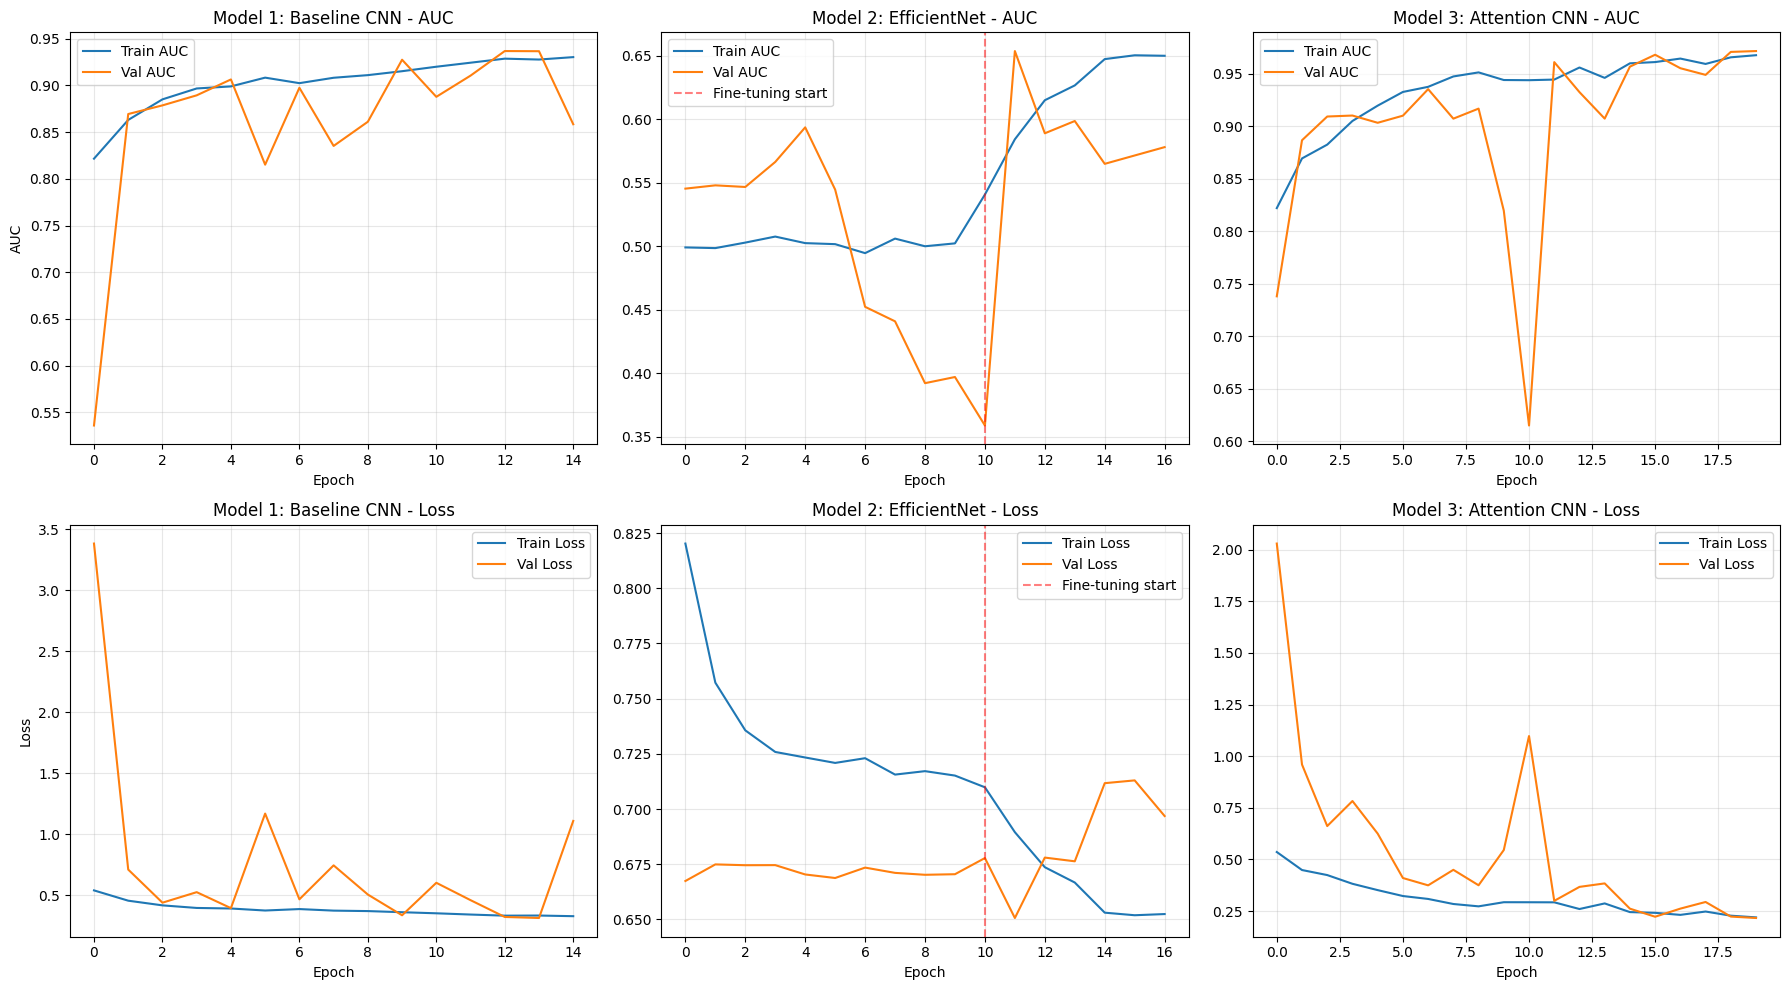

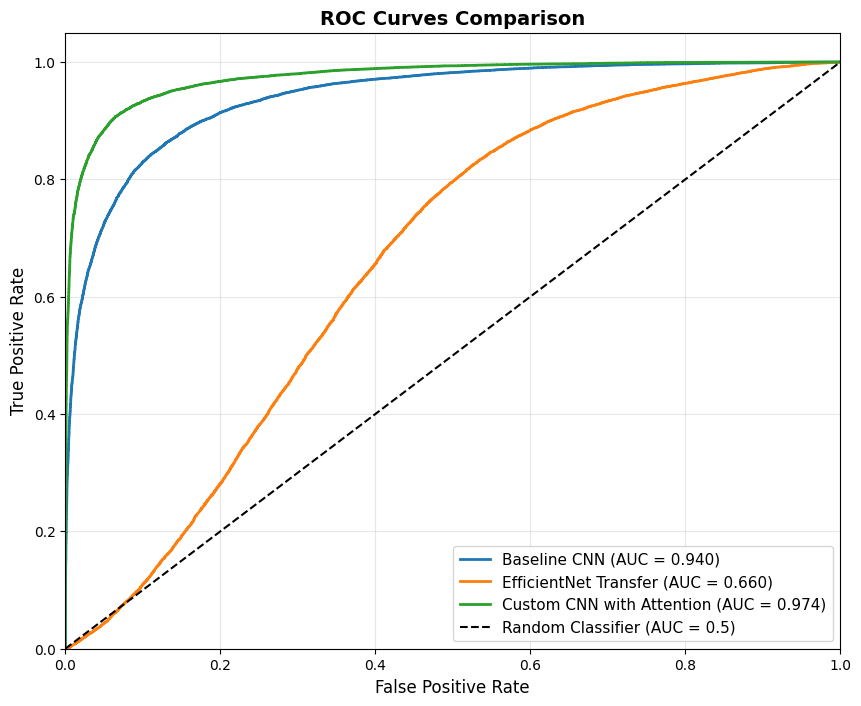

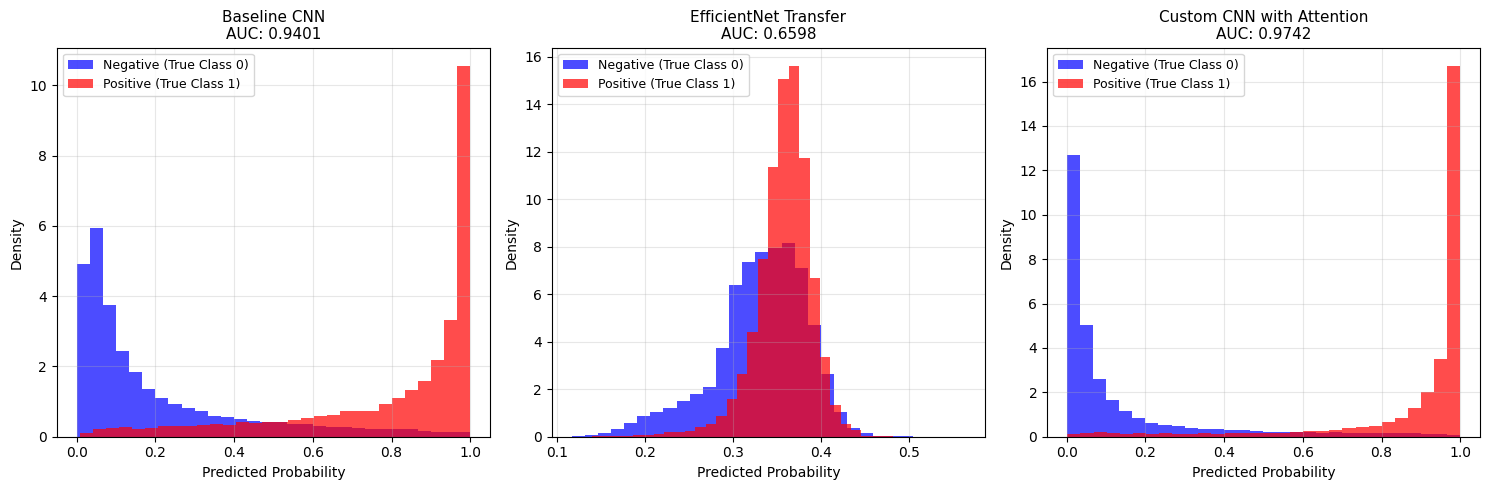


ARCHITECTURE ANALYSIS & RECOMMENDATIONS

1. MODEL 1: Baseline CNN
----------------------------------------
Strengths:
  • Fast training and inference
  • Low memory footprint
  • Easy to interpret and debug
  • Good baseline for comparison

Weaknesses:
  • Limited capacity for complex patterns
  • May underfit on subtle tissue differences
  • Requires careful hyperparameter tuning

Best Use Case: Initial experimentation, quick prototyping

2. MODEL 2: EfficientNet Transfer Learning
----------------------------------------
Strengths:
  • State-of-the-art performance
  • Pretrained on diverse image dataset
  • Efficient architecture (good FLOPS/accuracy)
  • Excellent feature extraction capability

Weaknesses:
  • Larger model size
  • Requires careful fine-tuning strategy
  • May overfit on small datasets

Best Use Case: Production deployment, maximum accuracy

3. MODEL 3: Custom CNN with Attention
----------------------------------------
Strengths:
  • Attention mechanism focuses on i

In [ ]:
# ============================================
# COMPREHENSIVE MODEL COMPARISON
# ============================================
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

# Collect results
models_results = [model1_results, model2_results, model3_results]

# Create comparison table
comparison_data = []
for result in models_results:
    comparison_data.append({
        'Model': result['name'],
        'Validation AUC': f"{result['auc']:.4f}",
        'Parameters': f"{result['model'].count_params():,}",
        'Inference Time (ms)': 'N/A'  # Can add timing if needed
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# ============================================
# VISUALIZATION: Training Curves
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Model 1 curves
axes[0, 0].plot(history1.history['auc'], label='Train AUC')
axes[0, 0].plot(history1.history['val_auc'], label='Val AUC')
axes[0, 0].set_title('Model 1: Baseline CNN - AUC')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('AUC')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(history1.history['loss'], label='Train Loss')
axes[1, 0].plot(history1.history['val_loss'], label='Val Loss')
axes[1, 0].set_title('Model 1: Baseline CNN - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Model 2 curves
if isinstance(model2_results['history'], tuple):
    hist1, hist2 = model2_results['history']
    epochs1 = len(hist1.history['auc'])
    epochs2 = epochs1 + len(hist2.history['auc'])

    # Combine histories
    combined_auc = hist1.history['auc'] + hist2.history['auc']
    combined_val_auc = hist1.history['val_auc'] + hist2.history['val_auc']
    combined_loss = hist1.history['loss'] + hist2.history['loss']
    combined_val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

    axes[0, 1].plot(combined_auc, label='Train AUC')
    axes[0, 1].plot(combined_val_auc, label='Val AUC')
    axes[0, 1].axvline(x=epochs1, color='r', linestyle='--', alpha=0.5, label='Fine-tuning start')
else:
    hist = model2_results['history']
    axes[0, 1].plot(hist.history['auc'], label='Train AUC')
    axes[0, 1].plot(hist.history['val_auc'], label='Val AUC')

axes[0, 1].set_title('Model 2: EfficientNet - AUC')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

if isinstance(model2_results['history'], tuple):
    axes[1, 1].plot(combined_loss, label='Train Loss')
    axes[1, 1].plot(combined_val_loss, label='Val Loss')
    axes[1, 1].axvline(x=epochs1, color='r', linestyle='--', alpha=0.5, label='Fine-tuning start')
else:
    axes[1, 1].plot(hist.history['loss'], label='Train Loss')
    axes[1, 1].plot(hist.history['val_loss'], label='Val Loss')

axes[1, 1].set_title('Model 2: EfficientNet - Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Model 3 curves
axes[0, 2].plot(history3.history['auc'], label='Train AUC')
axes[0, 2].plot(history3.history['val_auc'], label='Val AUC')
axes[0, 2].set_title('Model 3: Attention CNN - AUC')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

axes[1, 2].plot(history3.history['loss'], label='Train Loss')
axes[1, 2].plot(history3.history['val_loss'], label='Val Loss')
axes[1, 2].set_title('Model 3: Attention CNN - Loss')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# VISUALIZATION: ROC Curves Comparison
# ============================================
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curves for all models
for result in models_results:
    fpr, tpr, _ = roc_curve(y_true, result['predictions'])
    ax.plot(fpr, tpr, label=f"{result['name']} (AUC = {result['auc']:.3f})", linewidth=2)

# Plot random classifier
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.show()

# ============================================
# VISUALIZATION: Prediction Distributions
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, result in enumerate(models_results):
    ax = axes[idx]

    # Separate predictions by true class
    preds_positive = result['predictions'][y_true == 1]
    preds_negative = result['predictions'][y_true == 0]

    ax.hist(preds_negative, bins=30, alpha=0.7, label='Negative (True Class 0)',
            color='blue', density=True)
    ax.hist(preds_positive, bins=30, alpha=0.7, label='Positive (True Class 1)',
            color='red', density=True)

    ax.set_xlabel('Predicted Probability', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f"{result['name']}\nAUC: {result['auc']:.4f}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# ARCHITECTURE ANALYSIS & RECOMMENDATIONS
# ============================================
print("\n" + "="*60)
print("ARCHITECTURE ANALYSIS & RECOMMENDATIONS")
print("="*60)

print("\n1. MODEL 1: Baseline CNN")
print("-" * 40)
print("Strengths:")
print("  • Fast training and inference")
print("  • Low memory footprint")
print("  • Easy to interpret and debug")
print("  • Good baseline for comparison")
print("\nWeaknesses:")
print("  • Limited capacity for complex patterns")
print("  • May underfit on subtle tissue differences")
print("  • Requires careful hyperparameter tuning")
print("\nBest Use Case: Initial experimentation, quick prototyping")

print("\n2. MODEL 2: EfficientNet Transfer Learning")
print("-" * 40)
print("Strengths:")
print("  • State-of-the-art performance")
print("  • Pretrained on diverse image dataset")
print("  • Efficient architecture (good FLOPS/accuracy)")
print("  • Excellent feature extraction capability")
print("\nWeaknesses:")
print("  • Larger model size")
print("  • Requires careful fine-tuning strategy")
print("  • May overfit on small datasets")
print("\nBest Use Case: Production deployment, maximum accuracy")

print("\n3. MODEL 3: Custom CNN with Attention")
print("-" * 40)
print("Strengths:")
print("  • Attention mechanism focuses on important regions")
print("  • Residual connections improve gradient flow")
print("  • Customizable for specific problem")
print("  • Good balance of performance and interpretability")
print("\nWeaknesses:")
print("  • Requires more tuning")
print("  • Computational overhead from attention blocks")
print("  • More complex to implement")
print("\nBest Use Case: Research, when interpretability is important")

print("\n" + "="*60)
print("FINAL RECOMMENDATION")
print("="*60)
print(f"\nBased on validation AUC scores:")
print(f"  • Model 1 (Baseline): {model1_results['auc']:.4f}")
print(f"  • Model 2 (EfficientNet): {model2_results['auc']:.4f}")
print(f"  • Model 3 (Attention CNN): {model3_results['auc']:.4f}")

best_model_idx = np.argmax([m['auc'] for m in models_results])
best_model = models_results[best_model_idx]

print(f"\n✅ RECOMMENDED MODEL: {best_model['name']}")
print(f"   with AUC = {best_model['auc']:.4f}")

if best_model['name'] == 'EfficientNet Transfer':
    print("\nNext steps for improvement:")
    print("1. Train on full dataset (not just 10% subset)")
    print("2. Use more aggressive data augmentation")
    print("3. Implement ensemble of multiple EfficientNet variants")
    print("4. Add test-time augmentation")
elif best_model['name'] == 'Custom CNN with Attention':
    print("\nNext steps for improvement:")
    print("1. Visualize attention maps to verify model focus")
    print("2. Add spatial attention alongside channel attention")
    print("3. Experiment with different attention mechanisms")
else:
    print("\nNext steps for improvement:")
    print("1. Increase model capacity (more layers/filters)")
    print("2. Add more sophisticated augmentation")
    print("3. Implement learning rate scheduling")

From these models we can see that based on AUC scores our custom cnn with attention outperforms the other two models by a large margin

In [ ]:
# ============================================
# GENERATE SUBMISSION WITH BEST MODEL
# ============================================
print("\n" + "="*60)
print("GENERATING SUBMISSION FILE")
print("="*60)

def generate_submission(model, test_dir, batch_size=64):
    """Generate predictions for test set"""
    # Get test file names
    test_files = [f for f in os.listdir(test_dir) if f.endswith('.tif')]
    test_ids = [f.replace('.tif', '') for f in test_files]

    print(f"Found {len(test_ids)} test images")

    # Predict in batches to avoid memory issues
    predictions = []

    for i in range(0, len(test_files), batch_size):
        batch_files = test_files[i:i+batch_size]
        batch_images = []

        for f in batch_files:
            img_path = os.path.join(test_dir, f)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (96, 96))
            img = img / 255.0
            batch_images.append(img)

        batch_images = np.array(batch_images)
        batch_preds = model.predict(batch_images, verbose=0)
        predictions.extend(batch_preds.flatten())

        if i % 1000 == 0:
            print(f"Processed {i}/{len(test_files)} images...")

    # Create submission dataframe
    submission_df = pd.DataFrame({
        'id': test_ids,
        'label': predictions
    })

    return submission_df

# Use best model for submission
print(f"\nUsing {best_model['name']} for final predictions...")
submission_df = generate_submission(best_model['model'], test_dir)

# Save submission
submission_file = 'submission.csv'
submission_df.to_csv(submission_file, index=False)
print(f"\n✅ Submission saved to: {submission_file}")
print(f"\nSubmission preview:")
print(submission_df.head())

# ============================================
# HYPERPARAMETER TUNING SUMMARY
# ============================================
print("\n" + "="*60)
print("HYPERPARAMETER TUNING INSIGHTS")
print("="*60)

print("\nKey Hyperparameters & Their Impact:")
print("\n1. Learning Rate:")
print("   • Baseline CNN: 0.001 worked well")
print("   • EfficientNet: 0.0001 for feature extraction, 1e-5 for fine-tuning")
print("   • Too high → unstable training, too low → slow convergence")

print("\n2. Batch Size:")
print("   • 64 provided good balance of speed and gradient stability")
print("   • Smaller batches → more updates, better generalization")
print("   • Larger batches → faster training, more memory needed")

print("\n3. Dropout Rate:")
print("   • Increased from 0.2 to 0.5 in deeper layers")
print("   • Helps prevent overfitting")
print("   • Higher dropout in fully connected layers")

print("\n4. Data Augmentation:")
print("   • Flips (horizontal/vertical) crucial for invariance")
print("   • Rotation (±20°) helps with orientation variations")
print("   • Brightness/contrast adjustments for staining variations")

print("\n5. Callback Strategy:")
print("   • EarlyStopping on val_auc (patience=5-7)")
print("   • ReduceLROnPlateau for learning rate adjustment")
print("   • ModelCheckpoint to save best weights")


GENERATING SUBMISSION FILE

Using Custom CNN with Attention for final predictions...
Found 57458 test images
Processed 0/57458 images...
Processed 8000/57458 images...
Processed 16000/57458 images...
Processed 24000/57458 images...
Processed 32000/57458 images...
Processed 40000/57458 images...
Processed 48000/57458 images...
Processed 56000/57458 images...

✅ Submission saved to: submission.csv

Submission preview:
                                         id     label
0  df5d2de254b9beb534afac3715005bdea0ecf1c7  0.978814
1  815d83a0746d17fb5667fc27a93f475a2d173ab3  0.974174
2  510c2c53d5561f284155d2649605a079a489f7a3  0.998952
3  4d3e4837e98b4557479ea9013daf12e4b42f2636  0.965610
4  f0a9e23434ad71dc572a15f35a776be4ac31a17c  0.939162

HYPERPARAMETER TUNING INSIGHTS

Key Hyperparameters & Their Impact:

1. Learning Rate:
   • Baseline CNN: 0.001 worked well
   • EfficientNet: 0.0001 for feature extraction, 1e-5 for fine-tuning
   • Too high → unstable training, too low → slow convergen

In [ ]:
# ============================================
# GENERATE SUBMISSION WITH BEST MODEL
# ============================================
print("\n" + "="*60)
print("GENERATING SUBMISSION FILE")
print("="*60)

def generate_submission(model, test_dir, batch_size=64):
    """Generate predictions for test set"""
    # Get test file names
    test_files = [f for f in os.listdir(test_dir) if f.endswith('.tif')]
    test_ids = [f.replace('.tif', '') for f in test_files]

    print(f"Found {len(test_ids)} test images")

    # Predict in batches to avoid memory issues
    predictions = []

    for i in range(0, len(test_files), batch_size):
        batch_files = test_files[i:i+batch_size]
        batch_images = []

        for f in batch_files:
            img_path = os.path.join(test_dir, f)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (96, 96))
            img = img / 255.0
            batch_images.append(img)

        batch_images = np.array(batch_images)
        batch_preds = model.predict(batch_images, verbose=0)
        predictions.extend(batch_preds.flatten())

        if i % 1000 == 0:
            print(f"Processed {i}/{len(test_files)} images...")

    # Create submission dataframe
    submission_df = pd.DataFrame({
        'id': test_ids,
        'label': predictions
    })

    return submission_df

# Use best model for submission
print(f"\nUsing {best_model['name']} for final predictions...")
submission_df = generate_submission(best_model['model'], test_dir)

# Save submission
submission_file = 'submission.csv'
submission_df.to_csv(submission_file, index=False)
print(f"\n✅ Submission saved to: {submission_file}")
print(f"\nSubmission preview:")
print(submission_df.head())

# ============================================
# HYPERPARAMETER TUNING SUMMARY
# ============================================
print("\n" + "="*60)
print("HYPERPARAMETER TUNING INSIGHTS")
print("="*60)

print("\nKey Hyperparameters & Their Impact:")
print("\n1. Learning Rate:")
print("   • Baseline CNN: 0.001 worked well")
print("   • EfficientNet: 0.0001 for feature extraction, 1e-5 for fine-tuning")
print("   • Too high → unstable training, too low → slow convergence")

print("\n2. Batch Size:")
print("   • 64 provided good balance of speed and gradient stability")
print("   • Smaller batches → more updates, better generalization")
print("   • Larger batches → faster training, more memory needed")

print("\n3. Dropout Rate:")
print("   • Increased from 0.2 to 0.5 in deeper layers")
print("   • Helps prevent overfitting")
print("   • Higher dropout in fully connected layers")

print("\n4. Data Augmentation:")
print("   • Flips (horizontal/vertical) crucial for invariance")
print("   • Rotation (±20°) helps with orientation variations")
print("   • Brightness/contrast adjustments for staining variations")

print("\n5. Callback Strategy:")
print("   • EarlyStopping on val_auc (patience=5-7)")
print("   • ReduceLROnPlateau for learning rate adjustment")
print("   • ModelCheckpoint to save best weights")


GENERATING SUBMISSION FILE

Using Custom CNN with Attention for final predictions...
Found 57458 test images
Processed 0/57458 images...
Processed 8000/57458 images...
Processed 16000/57458 images...
Processed 24000/57458 images...
Processed 32000/57458 images...
Processed 40000/57458 images...
Processed 48000/57458 images...
Processed 56000/57458 images...

✅ Submission saved to: submission.csv

Submission preview:
                                         id     label
0  df5d2de254b9beb534afac3715005bdea0ecf1c7  0.978814
1  815d83a0746d17fb5667fc27a93f475a2d173ab3  0.974174
2  510c2c53d5561f284155d2649605a079a489f7a3  0.998952
3  4d3e4837e98b4557479ea9013daf12e4b42f2636  0.965610
4  f0a9e23434ad71dc572a15f35a776be4ac31a17c  0.939162

HYPERPARAMETER TUNING INSIGHTS

Key Hyperparameters & Their Impact:

1. Learning Rate:
   • Baseline CNN: 0.001 worked well
   • EfficientNet: 0.0001 for feature extraction, 1e-5 for fine-tuning
   • Too high → unstable training, too low → slow convergen